# Pulser
The pulser provides the n-Tron with an input current simulating the detection of a particle at a sensor. 2 input pulsers are required for coincidence detection / TOF calculation.

TD = time until voltage rise

TR = time voltage starts rising

PW = time voltage stays at peak

TF = time voltage starts falling

PER = period of one full pulse cycle

NP = number of periods simulated


### Pulser 1 (V1):
TD: V = 0, t < 16.5ns

TR: V = 0.25V * $\frac{t-16.5ns}{2.9ns}$, 16.5ns $\leq$ t < 19.4ns

PW: V = 0.25V, 19.4ns $\leq$ t < 19.5ns

TF: V = 0.25V * $(1 - \frac{t-19.5ns}{2.9ns})$, 19.5ns $\leq$ t < 22.4ns

(after TF): V = 0, t $\geq$ 22.4ns

### Pulser 2 (V4):
TD: V = 0, t < 16.5ns

TR: V = 0.25V * $\frac{t-16.5ns}{2.9ns}$, 16.5ns $\leq$ t < 19.4ns

PW: V = 0.25V, 19.4ns $\leq$ t < 19.5ns

TF: V = 0.25V * $(1 - \frac{t-19.5ns}{2.9ns})$, 19.5ns $\leq$ t < 22.4ns

(after TF): V = 0, t $\geq$ 22.4ns

In [2]:
import numpy as np

def pulse(t, TD, TR, PW, TF, V1, V2):
    t1 = TD
    t2 = TD + TR
    t3 = TD + TR + PW
    t4 = TD + TR + PW + TF

    return np.piecewise(
        t,
        [t < t1,                                    # condition 1
        (t >= t1) & (t < t2),                       # condition 2
        (t >= t2) & (t < t3),                       # condition 3
        (t >= t3) & (t < t4),                       # condition 4
        t >= t4],                                   # condition 5
        [V1,                                        # value for condition 1
        lambda t: V1 + (V2 - V1) * (t - t1) / TR,   # function for condition 2
        V2,                                         # value for condition 3
        lambda t: V2 - (V2 - V1) * (t - t3) / TF,   # function for condition 4
        V1]                                         # value for condition 5
    )
# Pulse 1 (V1) values
TD1, TR1, PW1, TF1, PER1, NP1 = 16.5e-9, 2.9e-9, 0.1e-9, 2.9e-9, 10e-9, 1
# Pulse 2 (V4) values
TD2, TR2, PW2, TF2, PER2, NP2 = 1e-9, 2.9e-9, 0.1e-9, 2.9e-9, 10e-9, 1

V1_level, V2_level = 0., 0.25

def pulser1(t): # plug values into pulse function 
    return pulse(t, TD1, TR1, PW1, TF1, V1_level, V2_level) # VX_level = VX

def pulser2(t):
    return pulse(t, TD2, TR2, PW2, TF2, V1_level, V2_level) 

From Ohm's law: I = $\frac{V}{R}$

In [6]:
RP = 50
t=np.linspace(0, 30e-9, 2000)
current_pulser_1 = pulser1(t) / RP   # amps
current_pulser_2 = pulser2(t) / RP   # amps

### Pulser Current Trace

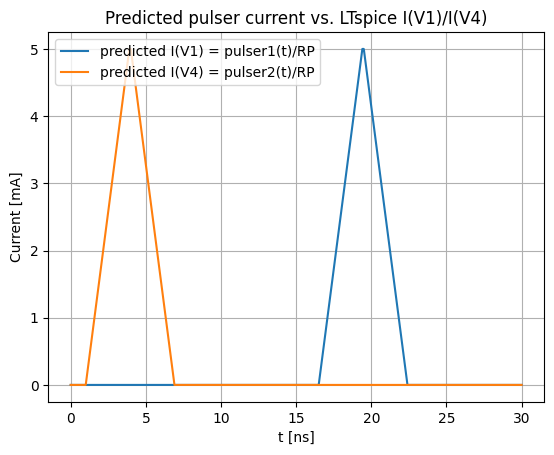

In [7]:
import matplotlib.pyplot as plt

t = np.linspace(0, 30e-9, 2000)   # (tmin, tmax, number of points in trace)

fig, ax = plt.subplots()
ax.plot(t * 1e9, current_pulser_1 * 1e3, label="predicted I(V1) = pulser1(t)/RP") ## s to ns, A to mA
ax.plot(t * 1e9, current_pulser_2 * 1e3, label="predicted I(V4) = pulser2(t)/RP")
ax.set_xlabel("t [ns]")
ax.set_ylabel("Current [mA]")
ax.set_title("Predicted pulser current vs. LTspice I(V1)/I(V4)")
ax.legend()
ax.grid(True)
plt.show()